<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_8_SemiParametric_Systematics_FNF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 8 — Semi-parametric systematics with Factorizable Normalizing Flows

The original Exercise 8 learns the endpoint ratios

$$
g_c^\pm(x)=\frac{p_c(x\mid\alpha=\pm1)}{p_c(x\mid\alpha=0)}
$$

and interpolates them point by point. HistFactory's nonlinear interpolation does not preserve the integral of the resulting shape, so that construction needs an explicit nuisance-dependent partition correction.

This variant follows the input-systematic construction of [Valsecchi, Donegà and Wallny, arXiv:2602.13184](https://arxiv.org/abs/2602.13184) and its [archived implementation](https://doi.org/10.5281/zenodo.21058119). For each selected process $c\in\{S,B\}$:

1. the nominal Exercise 5 hNDE $p_{c,0}(x)=p_{\rm ref}(x)r_c(x)/Z_c$ is loaded and frozen;
2. an invertible residual map $T_{c,\alpha}$ is trained on only the $\alpha=\pm1$ samples;
3. the nuisance-dependent shape is the pullback

$$
p_c(x\mid\alpha)
=
p_{c,0}\!\left(T_{c,\alpha}(x)\right)
\left|\det\frac{\partial T_{c,\alpha}(x)}{\partial x}\right|.
$$

The residual scale and shift are linear-plus-quadratic polynomials in $\alpha$, and $T_{c,0}$ is exactly the identity. Therefore

$$
\int p_c(x\mid\alpha)\,dx=1
$$

for every $\alpha$ by change of variables. The one fixed constant $Z_c$ is the nominal hNDE normalization already used in Exercise 5; there is no per-event interpolation of systematic density ratios and no nuisance-dependent partition function $Z_c(\alpha)$.

One distinction remains essential. The flow describes the **shape conditional on passing the fixed PRESEL region**. The nuisance-dependent selected yield $\nu_c(\alpha)$ is an independent extended-likelihood term because the detector response changes the selection efficiency. This notebook validates the learned deformation against the analytic Gaussian-mixture density, tests intermediate nuisance values that were not used for training, verifies normalization without rescaling, and finally demonstrates two-dimensional Asimov closure in $(\mu,\alpha)$.


In [1]:
## ============================================================================
# Google Colab setup — run me first. Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
N_BKG, N_SIG = 100_000_000, 20_000_000
USE_DRIVE = True
REMAKE_EVENTS = False
# ----------------------------------------------------------------------------

import subprocess
from pathlib import Path

DEPENDENCIES = [
    "pytorch-lightning",
    "onnx",
    "onnxruntime",
    "onnxscript",
    "iminuit",
    "mplhep",
    "nflows",  # reconstruct the saved Exercise 5 spline flow
    "pyarrow",
]


def run(*args, env=None):
    """Run one setup command and stop immediately if it fails."""
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"

    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)

    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )

    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    run(sys.executable, "-m", "pip", "install", "-q", *DEPENDENCIES)

    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)

    nominal_paths = [
        Path("dataframes/background.parquet"),
        Path("dataframes/signal.parquet"),
    ]
    variation_paths = [
        Path(f"dataframes/{process}_scale_{direction}.parquet")
        for process in ["background", "signal"]
        for direction in ["up", "down"]
    ]
    generator = TUTORIAL_DIR / "generate_distributions.py"
    if REMAKE_EVENTS or not all(path.exists() for path in nominal_paths):
        run(
            sys.executable, generator,
            "--n_bkg", N_BKG,
            "--n_sig", N_SIG,
            "--with-systematics",
            "--skip-data",
            "--skip-plots",
        )
    elif not all(path.exists() for path in variation_paths):
        run(sys.executable, generator, "--systematics-only")

print("Working dir:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


## Inputs and persisted models

The generated files contain

$$
p_B(x\mid-1),\ p_B(x\mid0),\ p_B(x\mid+1),
\qquad
p_S(x\mid-1),\ p_S(x\mid0),\ p_S(x\mid+1).
$$

The fixed PRESEL classifier, reference flow, and four-member signal/reference and background/reference ensembles are loaded from Exercise 5. Together they define exactly the same nominal hNDE densities used by the standard Exercise 8. The ONNX ratio networks are reconstructed as frozen PyTorch layers only to retain derivatives with respect to the transformed coordinates; no ratio or nominal flow is retrained.

Only the residual-flow checkpoints use an Exercise-8-FNF-specific directory. Nothing in the standard hNDE training path of Exercises 5--8 is modified. Completed figures are exported to `exercise8_fnf_figures_scripts/`.


In [2]:
import gc
import math
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import pyarrow.parquet as pq
import torch
from iminuit import Minuit
from IPython.display import display

from nsbi_common_utils.training.utils import load_trained_model
from utils import FEATURES, predict_with_model, predict_with_onnx
from utils_distributions import (
    background_components,
    signal_components,
    smearing_parameters,
)
from utils_fnf import (
    FNFExtendedLikelihood,
    analytic_selected_log_density,
    build_hybrid_nominal_density,
    fnf_log_prob_x,
    fnf_normalization_diagnostics,
    fnf_sample_x,
    hybrid_nominal_log_prob_x,
    hybrid_nominal_member_scores_x,
    log_quadratic_yield,
    train_factorizable_systematic_flow,
)
from utils_nf import (
    accumulate_preselection_histogram,
    choose_preselection_ratio_cut,
    collect_preselected_parquet,
    flow_sample_x,
    load_flow,
    sample_parquet_partition,
)
from utils_plotting import export_standalone_figure_script

FEATURES = list(FEATURES)
SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Features: {FEATURES}")


Using device: cuda
Features: ['x1', 'x2', 'x3', 'x4', 'x5']


In [3]:
BASE_PATH = Path("dataframes")
SAMPLE_PATHS = {
    ("signal", "nominal"): BASE_PATH / "signal.parquet",
    ("signal", "up"): BASE_PATH / "signal_scale_up.parquet",
    ("signal", "down"): BASE_PATH / "signal_scale_down.parquet",
    ("background", "nominal"): BASE_PATH / "background.parquet",
    ("background", "up"): BASE_PATH / "background_scale_up.parquet",
    ("background", "down"): BASE_PATH / "background_scale_down.parquet",
}

PRESEL_MODEL_DIR = Path("models_PRESEL")
REFERENCE_FLOW_MODEL_DIR = Path(
    "models_flows_hybrid_reference_spline16_tail5"
)
REFERENCE_FLOW_TYPE = "quadratic_spline"
NOMINAL_RATIO_MODEL_DIR = {
    "signal": Path("models_Hybrid_SigvsRef_5M_ensemble4"),
    "background": Path("models_Hybrid_BkgvsRef_5M_ensemble4"),
}
FNF_RESIDUAL_MODEL_DIR = Path(
    "models_Exercise8_FNF_hnde_systematic_residuals"
)
FIGURE_SCRIPT_DIR = Path("exercise8_fnf_figures_scripts")
for directory in [
    FNF_RESIDUAL_MODEL_DIR,
    FIGURE_SCRIPT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Reproduce the Exercise 5 data partitions and fixed PRESEL region.
SPLIT_SEED = 0
PRESEL_TRAIN_FRACTION = 0.5
FLOW_TRAIN_FRACTION = 0.92
STREAM_BATCH_SIZE = 100_000
PRESEL_CUT_HISTOGRAM_BINS = 4_000
PRESEL_LOG_RATIO_RANGE = (-20.0, 20.0)
PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO = 250.0
MAX_SELECTED_TRAIN_EVENTS = 1_000_000
MAX_EVAL_EVENTS = 250_000
NOMINAL_ENSEMBLE_SIZE = 4
RATIO_EVALUATION_BATCH_SIZE = 100_000
RATIO_FLOOR = 1.0e-12
ASIMOV_REFERENCE_EVENTS = 200_000
REFERENCE_SAMPLING_BATCH_SIZE = 65_536

# FNF residuals. The alpha-polynomial is the only nuisance dependence.
FNF_RESIDUAL_CONFIG = {
    "n_residual_layers": 2,
    "hidden_features": 128,
    "hidden_layers": 2,
    "quadratic_damping": 1.0,
    "log_scale_clip": 1.5,
    "shift_clip": 5.0,
}
FNF_RESIDUAL_TRAINING_CONFIG = {
    "max_events_per_anchor": 500_000,
    "max_validation_events_per_anchor": 200_000,
    "batch_size": 4096,
    "n_epochs": 60,
    "learning_rate": 1.0e-4,
    "weight_decay": 1.0e-6,
    "validation_fraction": 0.20,
    "patience": 12,
    "gradient_clip": 5.0,
    "lr_scheduler_factor": 0.2,
    "lr_scheduler_patience": 3,
    "min_learning_rate": 1.0e-7,
}
LOAD_FNF_IF_AVAILABLE = True

VALIDATION_EVENTS_PER_POINT = 25_000
NORMALIZATION_REFERENCE_EVENTS = 100_000
SCAN_REFERENCE_EVENTS = 40_000


def export_exercise8_fnf_figure(fig, script_name):
    return export_standalone_figure_script(
        fig, script_name=script_name, output_dir=FIGURE_SCRIPT_DIR
    )


missing_samples = [str(path) for path in SAMPLE_PATHS.values() if not path.exists()]
if missing_samples:
    raise FileNotFoundError(
        "Missing generated samples. Re-run the setup cell. Missing:\n"
        + "\n".join(missing_samples)
    )

print(f"Standalone figure scripts: {FIGURE_SCRIPT_DIR}/")


Standalone figure scripts: exercise8_fnf_figures_scripts/


## Check the detector variations

Before training, inspect the parquet metadata and a bounded $x_1$ projection. The row counts and total expected yields are unchanged by construction. The histograms should show the coherent response shift, not a change of the latent event generator.


,process,variation,rows,row_groups,path
0,signal,nominal,20000000,200,dataframes/signal.parquet
1,signal,up,20000000,200,dataframes/signal_scale_up.parquet
2,signal,down,20000000,200,dataframes/signal_scale_down.parquet
3,background,nominal,100000000,1000,dataframes/background.parquet
4,background,up,100000000,1000,dataframes/background_scale_up.parquet
5,background,down,100000000,1000,dataframes/background_scale_down.parquet


Wrote standalone figure script: exercise8_fnf_figures_scripts/detector_scale_variations_x1.py


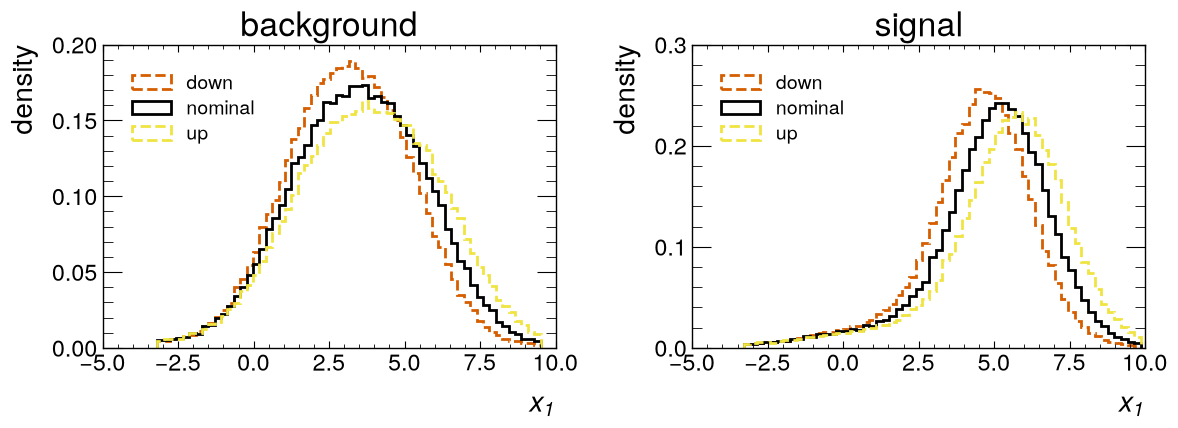

In [4]:
sample_summary = []
for (process, variation), path in SAMPLE_PATHS.items():
    parquet = pq.ParquetFile(path)
    sample_summary.append(
        {
            "process": process,
            "variation": variation,
            "rows": parquet.metadata.num_rows,
            "row_groups": parquet.metadata.num_row_groups,
            "path": str(path),
        }
    )
display(pd.DataFrame(sample_summary))


def first_parquet_batch(path, columns, n_rows=100_000):
    parquet = pq.ParquetFile(path)
    batch = next(parquet.iter_batches(batch_size=int(n_rows), columns=columns))
    return batch.to_pandas()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, process in zip(axes, ["background", "signal"]):
    batches = {
        variation: first_parquet_batch(
            SAMPLE_PATHS[(process, variation)], ["x1"]
        )
        for variation in ["nominal", "up", "down"]
    }
    combined = np.concatenate(
        [batch["x1"].to_numpy() for batch in batches.values()]
    )
    bins = np.linspace(
        np.quantile(combined, 0.005), np.quantile(combined, 0.995), 61
    )
    for variation, color, linestyle in [
        ("down", "C0", "--"),
        ("nominal", "black", "-"),
        ("up", "C3", "--"),
    ]:
        ax.hist(
            batches[variation]["x1"],
            bins=bins,
            density=True,
            histtype="step",
            lw=2,
            ls=linestyle,
            color=color,
            label=variation,
        )
    ax.set_title(process)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel("density")
    ax.legend()
fig.tight_layout()
export_exercise8_fnf_figure(fig, "detector_scale_variations_x1")
plt.show()


## Load the Exercise 5 nominal hNDE checkpoints

The PRESEL score defines one fixed analysis region. Its threshold is re-derived from the same nominal row partition used in Exercise 5 and is then applied unchanged to nominal, up, and down samples. The four saved process/reference ratio members and the reference flow will provide the frozen nominal density; this notebook trains none of them.


In [5]:
def require_checkpoint(path, explanation):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. {explanation}")
    return path


def as_inference_session(model_candidate):
    if isinstance(model_candidate, ort.InferenceSession):
        return model_candidate
    available = ort.get_available_providers()
    providers = [
        provider
        for provider in ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if provider in available
    ] or available
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    return ort.InferenceSession(
        model_candidate.SerializeToString(),
        sess_options=options,
        providers=providers,
    )


def load_ratio_pack(model_dir, ensemble_index):
    suffix = "" if ensemble_index is None else str(ensemble_index)
    model_path = require_checkpoint(
        Path(model_dir) / f"model{suffix}.onnx",
        "Run Exercise 5 through the corresponding training cells first.",
    )
    scaler_path = require_checkpoint(
        Path(model_dir) / f"model_scaler{suffix}.bin",
        "Run Exercise 5 through the corresponding training cells first.",
    )
    scaler, model_proto = load_trained_model(
        str(model_path), str(scaler_path)
    )
    return {
        "scaler": scaler,
        "model_proto": model_proto,
        "model": as_inference_session(model_proto),
        "path": model_path,
    }


PRESEL_pack = load_ratio_pack(PRESEL_MODEL_DIR, 0)
NOMINAL_RATIO_MODELS = {
    process: [
        load_ratio_pack(NOMINAL_RATIO_MODEL_DIR[process], member)
        for member in range(NOMINAL_ENSEMBLE_SIZE)
    ]
    for process in ["signal", "background"]
}


def evaluate_ratio_packs(packs, feature_dataframe, batch_size=100_000):
    chunks = []
    for start in range(0, len(feature_dataframe), int(batch_size)):
        batch = feature_dataframe.iloc[start : start + int(batch_size)][FEATURES]
        member_ratios = []
        for pack in packs:
            ratio = predict_with_model(
                batch.astype("float32", copy=False),
                scaler=pack["scaler"],
                model=pack["model"],
            )
            member_ratios.append(
                np.asarray(ratio, dtype=np.float64).reshape(-1)
            )
        chunks.append(np.mean(np.stack(member_ratios, axis=0), axis=0))
    values = np.concatenate(chunks) if chunks else np.empty(0)
    if not np.isfinite(values).all():
        raise FloatingPointError("A ratio model returned NaN or infinity.")
    return np.maximum(values, RATIO_FLOOR)


def evaluate_PRESEL_ratio(feature_dataframe, batch_size=100_000):
    return evaluate_ratio_packs(
        [PRESEL_pack], feature_dataframe, batch_size=batch_size
    )


print("Loaded PRESEL and both four-member nominal Exercise 5 ensembles.")


Loaded PRESEL and both four-member nominal Exercise 5 ensembles.


## Reconstruct the Exercise 5 selection

The PRESEL threshold is re-derived from the nominal flow-training partition using the same deterministic row split and target $B/S$. The resulting threshold is then applied unchanged to all nominal, up, and down samples. This is essential: a systematic variation changes the acceptance of a fixed analysis region; the selection itself must not be retuned for each template.


In [6]:
PRESEL_INPUT_STATS = {}
for process in ["signal", "background"]:
    _, stats = sample_parquet_partition(
        SAMPLE_PATHS[(process, "nominal")],
        features=FEATURES,
        partition="presel",
        max_events=1,
        batch_size=STREAM_BATCH_SIZE,
        presel_fraction=PRESEL_TRAIN_FRACTION,
        flow_train_fraction=FLOW_TRAIN_FRACTION,
        split_seed=SPLIT_SEED,
        reservoir_seed=SEED + (11 if process == "signal" else 22),
    )
    PRESEL_INPUT_STATS[process] = stats

PRESEL_INCLUSIVE_YIELD = {
    process: float(stats["inclusive_weight"])
    for process, stats in PRESEL_INPUT_STATS.items()
}
PRESEL_LOG_RATIO_EDGES = np.linspace(
    PRESEL_LOG_RATIO_RANGE[0],
    PRESEL_LOG_RATIO_RANGE[1],
    PRESEL_CUT_HISTOGRAM_BINS + 1,
)

histograms = {}
histogram_stats = {}
for process in ["signal", "background"]:
    histograms[process], histogram_stats[process] = (
        accumulate_preselection_histogram(
            SAMPLE_PATHS[(process, "nominal")],
            features=FEATURES,
            ratio_predictor=evaluate_PRESEL_ratio,
            log_ratio_edges=PRESEL_LOG_RATIO_EDGES,
            batch_size=STREAM_BATCH_SIZE,
            presel_fraction=PRESEL_TRAIN_FRACTION,
            flow_train_fraction=FLOW_TRAIN_FRACTION,
            split_seed=SPLIT_SEED,
        )
    )

PRESEL_RATIO_CUT, PRESEL_CUT_DIAGNOSTICS = choose_preselection_ratio_cut(
    histograms["signal"],
    histograms["background"],
    PRESEL_LOG_RATIO_EDGES,
    signal_inclusive_yield=PRESEL_INCLUSIVE_YIELD["signal"],
    background_inclusive_yield=PRESEL_INCLUSIVE_YIELD["background"],
    signal_partition_weight=histogram_stats["signal"]["partition_weight"],
    background_partition_weight=histogram_stats["background"]["partition_weight"],
    target_background_to_signal=PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO,
)

print(f"Fixed PRESEL ratio cut: r >= {PRESEL_RATIO_CUT:.6g}")
print(
    "Nominal histogram estimate at the cut: B/S = "
    f"{PRESEL_CUT_DIAGNOSTICS['histogram_background_to_signal']:.2f}"
)


Fixed PRESEL ratio cut: r >= 2.07508
Nominal histogram estimate at the cut: B/S = 249.78


In [7]:
SELECTED_SAMPLES = {}
SELECTED_STATS = {}
SELECTED_YIELD = {}

for sample_index, ((process, variation), path) in enumerate(SAMPLE_PATHS.items()):
    samples, stats = collect_preselected_parquet(
        path,
        features=FEATURES,
        ratio_predictor=evaluate_PRESEL_ratio,
        ratio_cut=PRESEL_RATIO_CUT,
        max_train_events=MAX_SELECTED_TRAIN_EVENTS,
        max_eval_events=MAX_EVAL_EVENTS,
        batch_size=STREAM_BATCH_SIZE,
        presel_fraction=PRESEL_TRAIN_FRACTION,
        flow_train_fraction=FLOW_TRAIN_FRACTION,
        split_seed=SPLIT_SEED,
        reservoir_seed=SEED + 1000 + 100 * sample_index,
    )
    train_stats = stats["flow_train"]
    if train_stats["partition_weight"] <= 0.0:
        raise RuntimeError(f"Empty flow-training partition for {(process, variation)}.")

    efficiency = (
        train_stats["selected_weight"] / train_stats["partition_weight"]
    )
    selected_yield = PRESEL_INCLUSIVE_YIELD[process] * efficiency
    SELECTED_YIELD[(process, variation)] = float(selected_yield)

    for split, dataframe in samples.items():
        retained_weight = float(dataframe["weight"].sum())
        if len(dataframe) == 0 or retained_weight <= 0.0:
            raise RuntimeError(
                f"No selected {(process, variation)} events in {split}."
            )
        dataframe["weight"] *= selected_yield / retained_weight

    SELECTED_SAMPLES[(process, variation)] = samples
    SELECTED_STATS[(process, variation)] = stats

selection_rows = []
for process in ["background", "signal"]:
    nominal_yield = SELECTED_YIELD[(process, "nominal")]
    for variation in ["down", "nominal", "up"]:
        stats = SELECTED_STATS[(process, variation)]["flow_train"]
        selection_rows.append(
            {
                "process": process,
                "variation": variation,
                "selected events": stats["selected_events"],
                "efficiency": (
                    stats["selected_weight"] / stats["partition_weight"]
                ),
                "selected yield": SELECTED_YIELD[(process, variation)],
                "yield / nominal": (
                    SELECTED_YIELD[(process, variation)] / nominal_yield
                ),
                "retained train": len(
                    SELECTED_SAMPLES[(process, variation)]["flow_train"]
                ),
                "retained eval": len(
                    SELECTED_SAMPLES[(process, variation)]["eval"]
                ),
            }
        )
display(pd.DataFrame(selection_rows))


,process,variation,selected events,efficiency,selected yield,yield / nominal,retained train,retained eval
0,background,down,5476288,0.119067,119067.050444,0.779339,1000000,250000
1,background,nominal,7026839,0.152780,152779.582388,1.000000,1000000,250000
2,background,up,8445840,0.183632,183631.915875,1.201940,1000000,250000
3,signal,down,4200081,0.456478,502.126072,0.820943,1000000,250000
4,signal,nominal,5116166,0.556041,611.645427,1.000000,1000000,250000
5,signal,up,5609355,0.609643,670.606922,1.096398,1000000,250000


## Load and freeze the nominal Exercise 5 hNDE densities

The FNF residual must deform the same normalized nominal density that is used in inference. We therefore reuse the Exercise 5 construction

$$
p_{c,0}(x)
=
p_{\rm ref}(x)\frac{\widehat r_c(x)}{Z_c},
\qquad
Z_c=\mathbb E_{p_{\rm ref}}[\widehat r_c].
$$

A fresh reference-flow sample supplies the same one-time nominal normalization used in Exercise 5 and the standard Exercise 8. The saved ONNX MLPs are reconstructed exactly as frozen PyTorch layers because residual maximum-likelihood training needs derivatives with respect to their input coordinates. The native classifier scores are compared member by member with ONNX Runtime. This comparison is intentionally performed before converting $s$ to $s/(1-s)$: in a saturated tail, a harmless float32 score difference can be strongly amplified by the odds transform. The differentiable copy is then used consistently for its own fixed normalization, reference weights, and density evaluation. No nominal flow and no ratio estimator is trained here.


In [8]:
def sample_preselected_reference_flow(
    flow_pack, n_events, batch_size=65_536
):
    """Draw from the Exercise 5 reference flow in the fixed PRESEL region."""
    accepted_chunks = []
    n_kept = 0
    n_generated = 0
    n_passed = 0
    while n_kept < int(n_events):
        current_batch = max(
            int(batch_size),
            min(int(n_events) - n_kept, 4 * int(batch_size)),
        )
        generated = flow_sample_x(
            flow_pack, current_batch, batch_size=batch_size
        )
        generated_frame = pd.DataFrame(generated, columns=FEATURES)
        passes = evaluate_PRESEL_ratio(generated_frame) >= PRESEL_RATIO_CUT
        n_generated += len(generated)
        n_passed += int(passes.sum())
        if np.any(passes):
            accepted = generated[passes]
            accepted_chunks.append(accepted)
            n_kept += len(accepted)
    accepted = np.concatenate(accepted_chunks, axis=0)[: int(n_events)]
    acceptance = n_passed / n_generated
    if not 0.0 < acceptance <= 1.0:
        raise RuntimeError("Invalid reference-flow PRESEL acceptance.")
    return accepted.astype(np.float32, copy=False), float(acceptance)


try:
    reference_flow = load_flow(
        "reference",
        model_dir=REFERENCE_FLOW_MODEL_DIR,
        flow_type=REFERENCE_FLOW_TYPE,
        device=device,
        expected_features=FEATURES,
    )
except FileNotFoundError as error:
    raise FileNotFoundError(
        f"Missing the Exercise 5 reference flow in {REFERENCE_FLOW_MODEL_DIR}. "
        "Run Exercise 5 through its reference-flow cell first."
    ) from error

np.random.seed(SEED + 30_000)
torch.manual_seed(SEED + 30_000)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 30_000)

REFERENCE_VALUES, REFERENCE_FLOW_PRESEL_ACCEPTANCE = (
    sample_preselected_reference_flow(
        reference_flow,
        ASIMOV_REFERENCE_EVENTS,
        batch_size=REFERENCE_SAMPLING_BATCH_SIZE,
    )
)
REFERENCE_DATAFRAME = pd.DataFrame(REFERENCE_VALUES, columns=FEATURES)

NOMINAL_RATIO_NORMALIZATION = {}
NOMINAL_RATIOS_REFERENCE = {}
HYBRID_NOMINAL_DENSITIES = {}
for process in ["signal", "background"]:
    HYBRID_NOMINAL_DENSITIES[process] = build_hybrid_nominal_density(
        process,
        reference_flow_pack=reference_flow,
        ratio_packs=NOMINAL_RATIO_MODELS[process],
        features=FEATURES,
        reference_sample=REFERENCE_VALUES,
        device=device,
        batch_size=RATIO_EVALUATION_BATCH_SIZE,
    )
    normalization = HYBRID_NOMINAL_DENSITIES[process][
        "ratio_normalization"
    ]
    normalized_ratio = HYBRID_NOMINAL_DENSITIES[process][
        "reference_sample_ratio"
    ]
    NOMINAL_RATIO_NORMALIZATION[process] = normalization
    NOMINAL_RATIOS_REFERENCE[process] = normalized_ratio

    n_equivalence = min(10_000, len(REFERENCE_DATAFRAME))
    equivalence_frame = REFERENCE_DATAFRAME.iloc[:n_equivalence]
    torch_scores = hybrid_nominal_member_scores_x(
        HYBRID_NOMINAL_DENSITIES[process],
        REFERENCE_VALUES[:n_equivalence],
    ).astype(np.float64)
    onnx_scores = np.stack(
        [
            predict_with_onnx(
                equivalence_frame,
                scaler=pack["scaler"],
                model=pack["model"],
            )
            for pack in NOMINAL_RATIO_MODELS[process]
        ],
        axis=0,
    ).astype(np.float64)
    max_score_difference = float(
        np.max(np.abs(torch_scores - onnx_scores))
    )
    if not np.allclose(
        torch_scores,
        onnx_scores,
        rtol=9.0e-3,
        atol=9.0e-3,
    ):
        raise RuntimeError(
            f"The differentiable {process} network does not reproduce "
            f"the ONNX classifier scores (max |delta s| = "
            f"{max_score_difference:.3e})."
        )
    component_weights = normalized_ratio / normalized_ratio.sum()
    effective_sample_size = 1.0 / np.sum(component_weights**2)
    print(
        f"{process:10s}: E_ref[raw r] = {normalization:.6f}; "
        f"E_ref[normalized r] = {normalized_ratio.mean():.12f}; "
        f"ESS = {effective_sample_size:,.0f}/{len(normalized_ratio):,}; "
        f"max Torch/ONNX |score difference| = "
        f"{max_score_difference:.3e}"
    )

print(
    f"Reference support: {len(REFERENCE_VALUES):,}; "
    f"PRESEL acceptance = {REFERENCE_FLOW_PRESEL_ACCEPTANCE:.4%}"
)
del NOMINAL_RATIO_MODELS, torch_scores, onnx_scores
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


signal    : E_ref[raw r] = 0.998668; E_ref[normalized r] = 1.000000000000; ESS = 191,047/200,000; max Torch/ONNX |score difference| = 1.045e-04
background: E_ref[raw r] = 1.000407; E_ref[normalized r] = 1.000000000000; ESS = 189,477/200,000; max Torch/ONNX |score difference| = 2.154e-04
Reference support: 200,000; PRESEL acceptance = 99.5628%


## Train the factorizable systematic residuals

For each process the residual is trained by maximum likelihood on the selected $\alpha=-1$ and $\alpha=+1$ samples while the complete nominal hNDE is frozen. In standardized coordinates each autoregressive layer has

$$
x_{{\rm nom},j}
=x_j\exp s_j(x_{<j},\alpha)+t_j(x_{<j},\alpha),
$$

with

$$
s_j=a^{(s)}_j(x_{<j})\alpha+b^{(s)}_j(x_{<j})\alpha^2,
\qquad
t_j=a^{(t)}_j(x_{<j})\alpha+b^{(t)}_j(x_{<j})\alpha^2.
$$

The coefficients are neural networks of the preceding features. The $\alpha$ factors make every residual layer exactly the identity at the nominal point. Training uses the deterministic Exercise 5 flow-training row partition, while validation uses its disjoint evaluation partition. Thus correlated up/down views of an underlying event cannot leak across the training boundary.


Loading existing signal FNF from models_Exercise8_FNF_hnde_systematic_residuals/fnf_signal.pt
Loading existing background FNF from models_Exercise8_FNF_hnde_systematic_residuals/fnf_background.pt
Wrote standalone figure script: exercise8_fnf_figures_scripts/fnf_residual_training_history.py


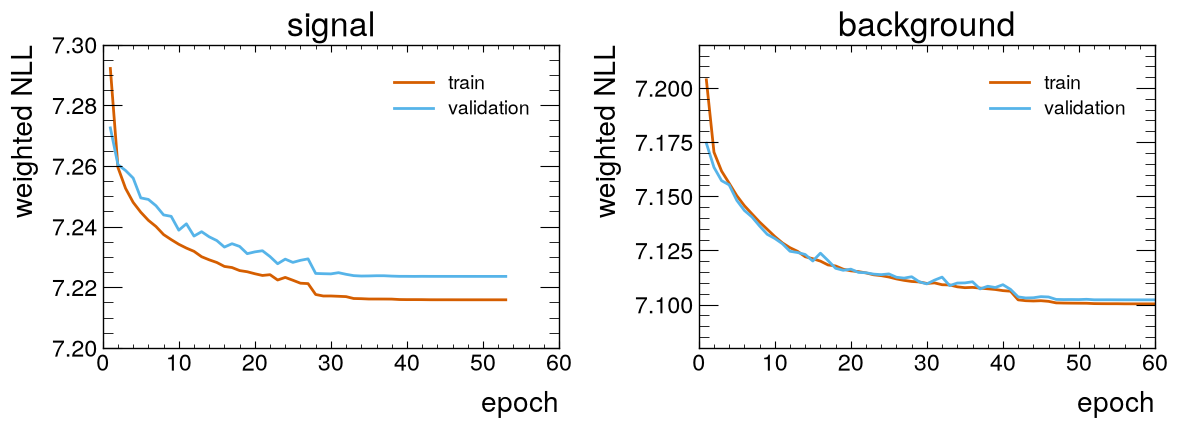

In [9]:
FNF_MODELS = {}
for process_index, process in enumerate(["signal", "background"]):
    FNF_MODELS[process] = train_factorizable_systematic_flow(
        process,
        base_density_pack=HYBRID_NOMINAL_DENSITIES[process],
        varied_samples={
            -1.0: SELECTED_SAMPLES[(process, "down")]["flow_train"],
            +1.0: SELECTED_SAMPLES[(process, "up")]["flow_train"],
        },
        validation_samples={
            -1.0: SELECTED_SAMPLES[(process, "down")]["eval"],
            +1.0: SELECTED_SAMPLES[(process, "up")]["eval"],
        },
        features=FEATURES,
        model_dir=FNF_RESIDUAL_MODEL_DIR,
        residual_config=FNF_RESIDUAL_CONFIG,
        training_config=FNF_RESIDUAL_TRAINING_CONFIG,
        device=device,
        load_if_available=LOAD_FNF_IF_AVAILABLE,
        seed=SEED + 40_000 + 1000 * process_index,
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, process in zip(axes, ["signal", "background"]):
    history = FNF_MODELS[process].get("history", {})
    epochs = np.arange(1, len(history.get("train_nll", [])) + 1)
    if len(epochs):
        ax.plot(epochs, history["train_nll"], lw=2, label="train")
        ax.plot(epochs, history["validation_nll"], lw=2, label="validation")
    ax.set_title(process)
    ax.set_xlabel("epoch")
    ax.set_ylabel("weighted NLL")
    ax.legend()
fig.tight_layout()
export_exercise8_fnf_figure(fig, "fnf_residual_training_history")
plt.show()


## Validation 1: compare with the analytic selected density

The reconstructed toy density is analytic. For a latent Gaussian component $z\sim\mathcal N(m,C)$ and detector response

$$
x=(1+0.1\alpha)\,S z+\epsilon,
\qquad
\epsilon\sim\mathcal N(0,R),
$$

the reconstructed component is

$$
x\sim\mathcal N\!\left((1+0.1\alpha)Sm,\,
(1+0.1\alpha)^2SCS^\mathsf T+R\right).
$$

Inside the fixed PRESEL region this density is divided by the corresponding selection efficiency. The following test compares the FNF log density with that analytic conditional density at the trained anchors and, more importantly, at $\alpha=\pm0.5$, which were never shown during training.


,process,alpha,training anchor,selection efficiency,correlation,log-density RMSE,log-density bias
0,signal,-1.0,True,0.456478,0.985193,0.253534,-0.035084
1,signal,-0.5,False,0.514040,0.989675,0.207179,-0.019754
2,signal,0.0,False,0.556041,0.992154,0.181649,-0.014645
3,signal,0.5,False,0.590000,0.979273,0.289124,-0.019483
4,signal,1.0,True,0.609643,0.985607,0.234632,-0.031236
5,background,-1.0,True,0.119067,0.986475,0.262506,-0.038589
6,background,-0.5,False,0.136775,0.987103,0.250047,-0.030201
7,background,0.0,False,0.152780,0.991826,0.194128,-0.017093
8,background,0.5,False,0.167073,0.984897,0.260807,-0.031371
9,background,1.0,True,0.183632,0.948412,0.488208,-0.034891


Wrote standalone figure script: exercise8_fnf_figures_scripts/fnf_analytic_log_density_parity.py


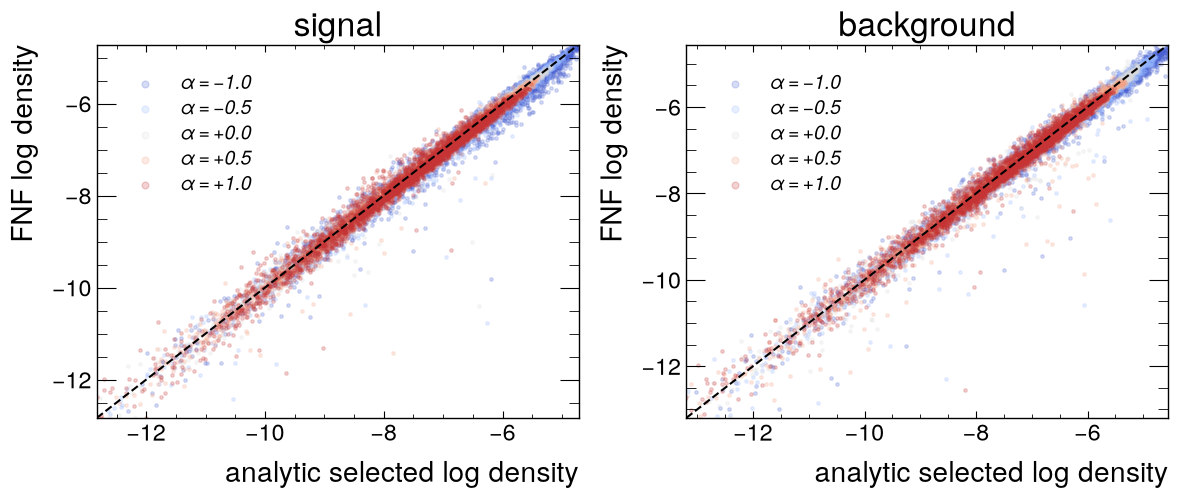

In [10]:
PROCESS_COMPONENTS = {
    "signal": signal_components(),
    "background": background_components(),
}
RESPONSE_SCALE, RESPONSE_RESOLUTION = smearing_parameters()


def sample_gaussian_mixture(components, n_events, rng):
    fractions = np.asarray([component[0] for component in components], dtype=float)
    fractions /= fractions.sum()
    counts = rng.multinomial(int(n_events), fractions)
    sample = np.empty((int(n_events), len(FEATURES)), dtype=np.float64)
    offset = 0
    for (_, mean, covariance), count in zip(components, counts):
        if count:
            sample[offset : offset + count] = rng.multivariate_normal(
                mean, covariance, size=count
            )
            offset += count
    rng.shuffle(sample)
    return sample


def sample_truth_selected(process, alpha, n_events, seed):
    rng = np.random.default_rng(seed)
    accepted = []
    n_generated = 0
    n_passed = 0
    while n_passed < int(n_events):
        current = max(50_000, 2 * (int(n_events) - n_passed))
        latent = sample_gaussian_mixture(
            PROCESS_COMPONENTS[process], current, rng
        )
        response_mean = (
            (1.0 + 0.1 * float(alpha))
            * latent
            * np.asarray(RESPONSE_SCALE)[None, :]
        )
        reconstructed = response_mean + rng.normal(
            loc=0.0,
            scale=np.asarray(RESPONSE_RESOLUTION)[None, :],
            size=response_mean.shape,
        )
        dataframe = pd.DataFrame(reconstructed, columns=FEATURES)
        passes = evaluate_PRESEL_ratio(dataframe) >= PRESEL_RATIO_CUT
        n_generated += current
        n_passed += int(passes.sum())
        if np.any(passes):
            accepted.append(reconstructed[passes])
    selected = np.concatenate(accepted, axis=0)[: int(n_events)]
    return selected.astype(np.float32), n_passed / n_generated


def anchor_validation_sample(process, alpha, n_events, seed):
    variation = {-1.0: "down", 0.0: "nominal", 1.0: "up"}[float(alpha)]
    dataframe = SELECTED_SAMPLES[(process, variation)]["eval"]
    n_keep = min(int(n_events), len(dataframe))
    values = dataframe.sample(n=n_keep, random_state=seed)[FEATURES].to_numpy(
        dtype=np.float32
    )
    efficiency = (
        SELECTED_YIELD[(process, variation)] / PRESEL_INCLUSIVE_YIELD[process]
    )
    return values, efficiency


VALIDATION_ALPHA_VALUES = [-1.0, -0.5, 0.0, 0.5, 1.0]
VALIDATION_SAMPLES = {}
validation_rows = []
parity_payload = {}

for process_index, process in enumerate(["signal", "background"]):
    parity_payload[process] = []
    for alpha_index, alpha in enumerate(VALIDATION_ALPHA_VALUES):
        local_seed = SEED + 50_000 + 1000 * process_index + 100 * alpha_index
        if alpha in {-1.0, 0.0, 1.0}:
            values, efficiency = anchor_validation_sample(
                process, alpha, VALIDATION_EVENTS_PER_POINT, local_seed
            )
        else:
            values, efficiency = sample_truth_selected(
                process, alpha, VALIDATION_EVENTS_PER_POINT, local_seed
            )
        VALIDATION_SAMPLES[(process, alpha)] = (values, efficiency)

        truth_log_density = analytic_selected_log_density(
            values,
            PROCESS_COMPONENTS[process],
            response_scale=RESPONSE_SCALE,
            resolution=RESPONSE_RESOLUTION,
            alpha=alpha,
            selection_efficiency=efficiency,
        )
        fnf_log_density = fnf_log_prob_x(
            FNF_MODELS[process], values, alpha
        ).astype(np.float64)
        difference = fnf_log_density - truth_log_density
        correlation = float(np.corrcoef(truth_log_density, fnf_log_density)[0, 1])
        validation_rows.append(
            {
                "process": process,
                "alpha": alpha,
                "training anchor": alpha in {-1.0, 1.0},
                "selection efficiency": efficiency,
                "correlation": correlation,
                "log-density RMSE": float(np.sqrt(np.mean(difference**2))),
                "log-density bias": float(np.mean(difference)),
            }
        )
        parity_payload[process].append(
            (alpha, truth_log_density, fnf_log_density)
        )

validation_table = pd.DataFrame(validation_rows)
display(validation_table)

colors = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(VALIDATION_ALPHA_VALUES)))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, process in zip(axes, ["signal", "background"]):
    low = np.inf
    high = -np.inf
    for color, (alpha, truth_log_density, fnf_log_density) in zip(
        colors, parity_payload[process]
    ):
        plot_indices = np.linspace(
            0, len(truth_log_density) - 1, min(3000, len(truth_log_density))
        ).astype(int)
        ax.scatter(
            truth_log_density[plot_indices],
            fnf_log_density[plot_indices],
            s=6,
            alpha=0.22,
            color=color,
            label=rf"$\alpha={alpha:+.1f}$",
        )
        low = min(low, np.quantile(truth_log_density, 0.005))
        high = max(high, np.quantile(truth_log_density, 0.995))
    ax.plot([low, high], [low, high], color="black", ls="--", lw=1.5)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_title(process)
    ax.set_xlabel("analytic selected log density")
    ax.set_ylabel("FNF log density")
    ax.legend(markerscale=2)
fig.tight_layout()
export_exercise8_fnf_figure(fig, "fnf_analytic_log_density_parity")
plt.show()


## Validation 2: generated closure at unseen nuisance values

The parity test probes density values. This complementary test importance-resamples the Exercise 5 reference support with the nominal process/reference ratio, transports those nominal hNDE draws through the inverse FNF map at $\alpha=\pm0.5$, and compares every marginal with an independently generated, analytically controlled truth sample after the same fixed PRESEL selection. It also reports how often FNF samples satisfy the PRESEL requirement; leakage outside the selected support is a direct diagnostic of density-model misspecification.


signal    , alpha=-0.5: FNF PRESEL pass fraction = 99.4640%
signal    , alpha=+0.5: FNF PRESEL pass fraction = 99.7120%
Wrote standalone figure script: exercise8_fnf_figures_scripts/fnf_signal_unseen_alpha_marginal_closure.py


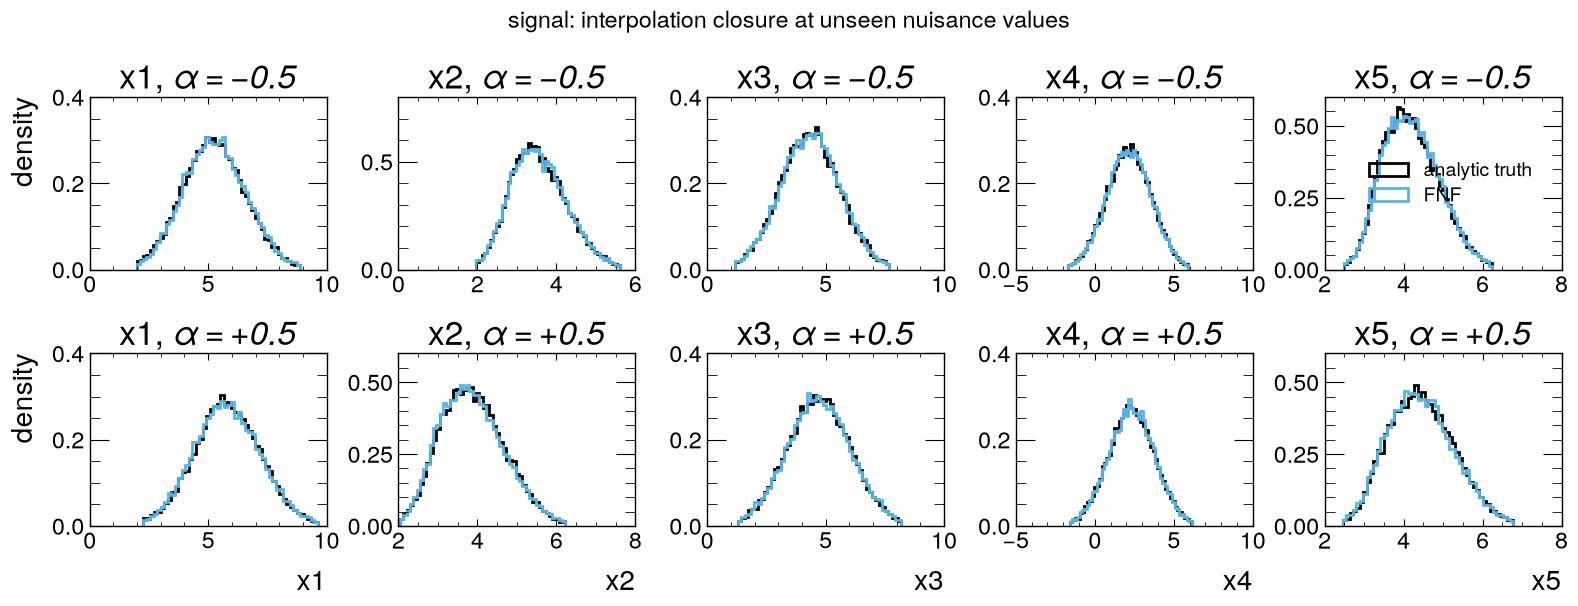

background, alpha=-0.5: FNF PRESEL pass fraction = 99.4040%
background, alpha=+0.5: FNF PRESEL pass fraction = 99.6480%
Wrote standalone figure script: exercise8_fnf_figures_scripts/fnf_background_unseen_alpha_marginal_closure.py


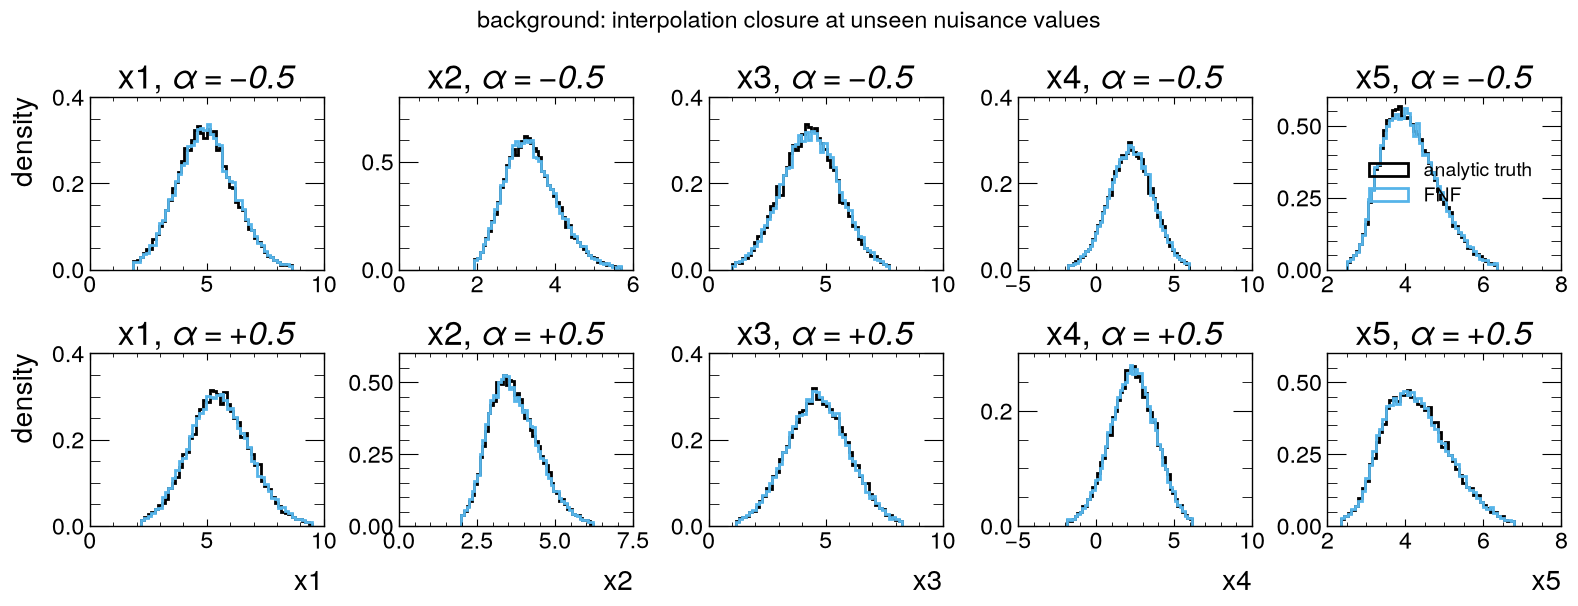

In [11]:
for process in ["signal", "background"]:
    fig, axes = plt.subplots(2, len(FEATURES), figsize=(16, 6.2))
    for row, alpha in enumerate([-0.5, 0.5]):
        truth_values, _ = VALIDATION_SAMPLES[(process, alpha)]
        fnf_values = fnf_sample_x(
            FNF_MODELS[process], len(truth_values), alpha
        )
        fnf_pass_fraction = np.mean(
            evaluate_PRESEL_ratio(
                pd.DataFrame(fnf_values, columns=FEATURES)
            )
            >= PRESEL_RATIO_CUT
        )
        print(
            f"{process:10s}, alpha={alpha:+.1f}: "
            f"FNF PRESEL pass fraction = {fnf_pass_fraction:.4%}"
        )

        for column, feature in enumerate(FEATURES):
            ax = axes[row, column]
            combined = np.concatenate(
                [truth_values[:, column], fnf_values[:, column]]
            )
            bins = np.linspace(
                np.quantile(combined, 0.005),
                np.quantile(combined, 0.995),
                51,
            )
            ax.hist(
                truth_values[:, column],
                bins=bins,
                density=True,
                histtype="step",
                lw=2,
                color="black",
                label="analytic truth",
            )
            ax.hist(
                fnf_values[:, column],
                bins=bins,
                density=True,
                histtype="step",
                lw=2,
                color="C1",
                label="FNF",
            )
            ax.set_title(rf"{feature}, $\alpha={alpha:+.1f}$")
            if column == 0:
                ax.set_ylabel("density")
            if row == 1:
                ax.set_xlabel(feature)
            if row == 0 and column == len(FEATURES) - 1:
                ax.legend()
    fig.suptitle(f"{process}: interpolation closure at unseen nuisance values")
    fig.tight_layout()
    export_exercise8_fnf_figure(
        fig, f"fnf_{process}_unseen_alpha_marginal_closure"
    )
    plt.show()


## Validation 3: normalization without a partition correction

The change-of-variables proof is exact. A finite-sample numerical check is nevertheless useful:

$$
\mathbb E_{x\sim p_c(\cdot\mid0)}
\left[
\frac{p_c(x\mid\alpha)}{p_c(x\mid0)}
\right]
=1.
$$

The first table verifies numerically that the residual is exactly the identity at $\alpha=0$. The second evaluates the integral identity with nominal hNDE draws obtained by importance-resampling the independent Exercise 5 reference support. Crucially, the systematic density ratios are **not divided by their sample mean**. Agreement with one is therefore a validation, not an imposed condition. The Monte-Carlo standard error and effective sample size quantify the precision of the check.


In [12]:
normalization_tables = []
identity_rows = []
for process in ["signal", "background"]:
    nominal_eval = SELECTED_SAMPLES[(process, "nominal")]["eval"].iloc[
        : min(50_000, len(SELECTED_SAMPLES[(process, "nominal")]["eval"]))
    ]
    fnf_nominal_log_density = fnf_log_prob_x(
        FNF_MODELS[process], nominal_eval, 0.0
    )
    base_nominal_log_density = hybrid_nominal_log_prob_x(
        HYBRID_NOMINAL_DENSITIES[process], nominal_eval
    )
    identity_rows.append(
        {
            "process": process,
            "max |log p_FNF(alpha=0) - log p_base|": float(
                np.max(
                    np.abs(
                        fnf_nominal_log_density - base_nominal_log_density
                    )
                )
            ),
        }
    )
    table = fnf_normalization_diagnostics(
        FNF_MODELS[process],
        [-1.0, -0.5, 0.0, 0.5, 1.0],
        n_reference=NORMALIZATION_REFERENCE_EVENTS,
    )
    table.insert(0, "process", process)
    normalization_tables.append(table)

normalization_table = pd.concat(normalization_tables, ignore_index=True)
display(pd.DataFrame(identity_rows))
display(normalization_table)

nontrivial = normalization_table["MC standard error"] > 0.0
if np.any(
    np.abs(normalization_table.loc[nontrivial, "(mean - 1) / SE"]) > 5.0
):
    warnings.warn(
        "At least one normalization check differs from one by more than "
        "five Monte-Carlo standard errors. Inspect the ratio tails and "
        "increase NORMALIZATION_REFERENCE_EVENTS before interpreting it."
    )


,process,max |log p_FNF(alpha=0) - log p_base|
0,signal,0.000628
1,background,0.000660


,process,alpha,mean density ratio,MC standard error,(mean - 1) / SE,ESS,reference events
0,signal,-1.0,0.989448,0.002062,-5.116733,69715.490031,100000
1,signal,-0.5,0.995527,0.001093,-4.092314,89244.205655,100000
2,signal,0.0,1.000000,0.000002,-0.178033,99999.968304,100000
3,signal,0.5,0.998491,0.001266,-1.191812,86150.378883,100000
4,signal,1.0,0.992241,0.002812,-2.758723,55451.208194,100000
5,background,-1.0,0.987961,0.002077,-5.797689,69359.902725,100000
6,background,-0.5,0.994786,0.001123,-4.641483,88691.433629,100000
7,background,0.0,1.000000,0.000002,-0.178033,99999.968304,100000
8,background,0.5,0.999225,0.001223,-0.634027,86973.165872,100000
9,background,1.0,0.994787,0.002589,-2.013517,59620.242059,100000


/tmp/ipykernel_42550/2287679389.py:41: UserWarning: At least one normalization check differs from one by more than five Monte-Carlo standard errors. Inspect the ratio tails and increase NORMALIZATION_REFERENCE_EVENTS before interpreting it.
  warnings.warn(


## Extended FNF likelihood and numerical Asimov closure

The selected yields are kept separate from the normalized shapes. Their three anchors are joined by the positive log-quadratic morph

$$
\nu_c(\alpha)
=\nu_c(0)\exp\!\left(a_c\alpha+b_c\alpha^2\right),
$$

where $a_c$ and $b_c$ are fixed by $\nu_c(-1)$ and $\nu_c(+1)$. The unbinned intensity is

$$
\lambda(x\mid\mu,\alpha)
=\mu\,\nu_S(\alpha)p_S(x\mid\alpha)
+\nu_B(\alpha)p_B(x\mid\alpha).
$$

The extended objective is

$$
-2\log L
=2\!\left[
\mu\nu_S(\alpha)+\nu_B(\alpha)
-\sum_i w_i^A\log\lambda(x_i\mid\mu,\alpha)
\right]
+\alpha^2.
$$

The numerical Asimov integral uses the same reference-flow support as the nominal Exercise 8. Its weights are

$$
w_i^A
=
\frac{\nu_S(0)\,\bar r_S(x_i)+\nu_B(0)\,\bar r_B(x_i)}{M},
$$

where each nominal ratio has unit mean on the reference support. This makes the $\mu$ score close algebraically at $(\mu,\alpha)=(1,0)$ for the empirical hNDE, exactly as in the nominal Exercise 8. No systematic shape normalization is estimated from these points; closure in the nuisance direction must emerge within the quoted integration precision.


In [13]:
nominal_signal_yield = SELECTED_YIELD[("signal", "nominal")]
nominal_background_yield = SELECTED_YIELD[("background", "nominal")]
asimov_events = REFERENCE_VALUES
asimov_weights = (
    nominal_signal_yield * NOMINAL_RATIOS_REFERENCE["signal"]
    + nominal_background_yield * NOMINAL_RATIOS_REFERENCE["background"]
) / len(asimov_events)
nominal_expected_yield = nominal_signal_yield + nominal_background_yield
print(
    f"Asimov weight closure: {asimov_weights.sum():.12f} versus "
    f"{nominal_expected_yield:.12f} expected"
)
if not np.isclose(
    asimov_weights.sum(), nominal_expected_yield, rtol=0.0, atol=1.0e-7
):
    raise RuntimeError("The reference-sampled nominal Asimov did not close.")

signal_yield_anchors = {
    variation: SELECTED_YIELD[("signal", variation)]
    for variation in ["down", "nominal", "up"]
}
background_yield_anchors = {
    variation: SELECTED_YIELD[("background", variation)]
    for variation in ["down", "nominal", "up"]
}

fnf_likelihood = FNFExtendedLikelihood(
    signal_fnf=FNF_MODELS["signal"],
    background_fnf=FNF_MODELS["background"],
    events=asimov_events,
    weights=asimov_weights,
    signal_yields=signal_yield_anchors,
    background_yields=background_yield_anchors,
    alpha_constraint_sigma=1.0,
    batch_size=4096,
)

truth_point = np.array([1.0, 0.0], dtype=np.float64)
truth_score = fnf_likelihood.model_grad(truth_point)

minimizer = Minuit(
    fnf_likelihood.model,
    truth_point,
    grad=fnf_likelihood.model_grad,
    name=("mu", "scale"),
)
minimizer.errordef = Minuit.LEAST_SQUARES
minimizer.limits["mu"] = (0.01, 3.0)
minimizer.limits["scale"] = (-2.0, 2.0)
minimizer.strategy = 0
fit_result = minimizer.migrad()
minimizer.hesse()
print(fit_result)

best_fit = {
    "mu": float(minimizer.values["mu"]),
    "scale": float(minimizer.values["scale"]),
}
print("Asimov truth score:", dict(zip(["mu", "scale"], truth_score)))
print("Profiled best fit:", best_fit)
print(
    "Closure: "
    f"mu_hat - 1 = {best_fit['mu'] - 1.0:+.6e}, "
    f"alpha_hat = {best_fit['scale']:+.6e}"
)

# Estimate the numerical-integration precision from disjoint reference blocks.
N_SCORE_BLOCKS = 8
block_scores = []
reference_blocks = np.array_split(
    np.arange(len(asimov_events)), N_SCORE_BLOCKS
)
for block_indices in reference_blocks:
    block_events = asimov_events[block_indices]
    block_weights = (
        nominal_signal_yield
        * NOMINAL_RATIOS_REFERENCE["signal"][block_indices]
        + nominal_background_yield
        * NOMINAL_RATIOS_REFERENCE["background"][block_indices]
    ) / len(block_indices)
    block_likelihood = FNFExtendedLikelihood(
        signal_fnf=FNF_MODELS["signal"],
        background_fnf=FNF_MODELS["background"],
        events=block_events,
        weights=block_weights,
        signal_yields=signal_yield_anchors,
        background_yields=background_yield_anchors,
        alpha_constraint_sigma=1.0,
        batch_size=4096,
    )
    block_scores.append(block_likelihood.model_grad(truth_point))

block_scores = np.asarray(block_scores)
score_standard_error = block_scores.std(axis=0, ddof=1) / np.sqrt(
    N_SCORE_BLOCKS
)
score_pull = np.divide(
    truth_score,
    score_standard_error,
    out=np.zeros_like(truth_score),
    where=score_standard_error > 0.0,
)
display(
    pd.DataFrame(
        {
            "parameter": ["mu", "scale"],
            "Asimov score": truth_score,
            "integration SE": score_standard_error,
            "score / SE": score_pull,
        }
    )
)


Asimov weight closure: 153391.227814686892 versus 153391.227814686863 expected
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.18e+06                  │        Nfcn = 405, Ngrad = 10        │
│ EDM = 0.00333 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────

,parameter,Asimov score,integration SE,score / SE
0,mu,0.000340,0.416733,0.000816
1,scale,740.344055,1030.606802,0.718357


### Profile-likelihood closure

For a transparent scan, a smaller reference-flow subset is used with the corresponding nominal hNDE Asimov weights. At each $\alpha$ the FNF densities are evaluated directly. The two-dimensional grid is then profiled numerically over the other coordinate. No HistFactory shape interpolation and no $Z_c(\alpha)$ enter the scan.


In [14]:
scan_events = asimov_events[:SCAN_REFERENCE_EVENTS]
scan_signal_ratio = NOMINAL_RATIOS_REFERENCE["signal"][
    :SCAN_REFERENCE_EVENTS
]
scan_background_ratio = NOMINAL_RATIOS_REFERENCE["background"][
    :SCAN_REFERENCE_EVENTS
]
scan_weights = (
    nominal_signal_yield * scan_signal_ratio
    + nominal_background_yield * scan_background_ratio
) / len(scan_events)

MU_GRID = np.linspace(0.5, 1.5, 51)
ALPHA_GRID = np.linspace(-0.05, 0.05, 41)
nll_grid = np.empty((len(ALPHA_GRID), len(MU_GRID)), dtype=np.float64)

for alpha_index, alpha in enumerate(ALPHA_GRID):
    log_p_signal = fnf_log_prob_x(
        FNF_MODELS["signal"], scan_events, alpha
    ).astype(np.float64)
    log_p_background = fnf_log_prob_x(
        FNF_MODELS["background"], scan_events, alpha
    ).astype(np.float64)
    signal_yield = float(
        log_quadratic_yield(
            alpha,
            nominal=signal_yield_anchors["nominal"],
            down=signal_yield_anchors["down"],
            up=signal_yield_anchors["up"],
        )
    )
    background_yield = float(
        log_quadratic_yield(
            alpha,
            nominal=background_yield_anchors["nominal"],
            down=background_yield_anchors["down"],
            up=background_yield_anchors["up"],
        )
    )
    for mu_index, mu in enumerate(MU_GRID):
        log_intensity = np.logaddexp(
            np.log(mu * signal_yield) + log_p_signal,
            np.log(background_yield) + log_p_background,
        )
        nll_grid[alpha_index, mu_index] = (
            2.0
            * (
                mu * signal_yield
                + background_yield
                - np.sum(scan_weights * log_intensity)
            )
            + alpha**2
        )

delta_nll_grid = nll_grid - np.min(nll_grid)
t_mu_profiled = np.min(delta_nll_grid, axis=0)
t_alpha_profiled = np.min(delta_nll_grid, axis=1)
grid_minimum = np.unravel_index(np.argmin(nll_grid), nll_grid.shape)
print(
    "Grid best fit: "
    f"mu={MU_GRID[grid_minimum[1]]:.6f}, "
    f"alpha={ALPHA_GRID[grid_minimum[0]]:.6f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(MU_GRID, t_mu_profiled, lw=2)
axes[0].axvline(1.0, color="black", ls=":", lw=1.3)
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$t_{\mu,A}$")
axes[0].set_ylim(bottom=0.0)
axes[0].set_title("FNF Asimov closure")

axes[1].plot(ALPHA_GRID, t_alpha_profiled, lw=2, color="C1")
axes[1].axvline(0.0, color="black", ls=":", lw=1.3)
axes[1].set_xlabel(r"$\alpha_{\rm scale}$")
axes[1].set_ylabel(r"$t_{\alpha,A}$")
axes[1].set_ylim(bottom=0.0)
axes[1].set_title("normalized nuisance deformation")
fig.tight_layout()
export_exercise8_fnf_figure(fig, "fnf_asimov_profile_closure")
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'square'

## What has—and has not—been normalized

- The nominal densities are the frozen Exercise 5 hNDEs, with one fixed process/reference ratio normalization $Z_c$ determined at $\alpha=0$.
- Every nuisance-dependent FNF shape is the pullback of its nominal hNDE, so it is normalized for all $\alpha$ by construction.
- The numerical normalization table never rescales a density ratio.
- The selected-yield response is not part of the conditional shape density. It is retained as the independent extended-rate factor $\nu_c(\alpha)$.
- The numerical Asimov support is an integration device, not a source of a fitted partition function. Increasing its size only reduces integration error.

This is the central difference from the original pointwise HistFactory morph. In that construction, normalized endpoint ratios do not imply a normalized interpolated density. Here the entire nuisance dependence lives inside an invertible map and its Jacobian, so normalization is a structural property of the model.

## Suggested exercises

1. Use only one Exercise 5 ratio member and observe how nominal-density accuracy affects the learned deformation even though formal FNF normalization remains exact.
2. Remove the quadratic nuisance coefficients and compare interpolation at $\alpha=\pm0.5$.
3. Train on $\alpha=\pm0.5$ instead of $\pm1$ and test extrapolation to the original anchors.
4. Hold the selected yields fixed to isolate a pure shape systematic.
5. Add a second independent nuisance and verify that the number of trained anchor samples grows linearly, while optional bilinear cross terms diagnose non-factorizing responses.
